## Importing relevant libraries

In [1]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

import mpltern
import ternary 

from sklearn.decomposition import PCA
from sklearn import preprocessing 
#may require %pip install scikit-learn

## Setting graph parameters

In [2]:
%matplotlib inline
plt.rcParams['font.sans-serif'] = 'Arial' # Choose a nice font here
plt.rcParams['font.size'] = 7 # standard font size
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial'
plt.rcParams['figure.facecolor'] = 'white' # make sure background isn't transparent
plt.rcParams['figure.dpi'] = 300

# Shared code blocks for compositional data

## Loading major element data

In [3]:
#data for ternary diagram and PCA
#available in github repository
biotites=pd.read_csv('monash_biotite.csv')

## Assigning colours for each slide

In [4]:
#code for assigning slide colours

ED_colours = {'EDC01':'royalblue',
              'EDC29B':'firebrick',
              'EDC08':'darkcyan',
              'EDC017':'lightgreen',
              'EDC02':'hotpink',
              'EDC024':'sandybrown'}

def colours (data_set_samples):
    return ED_colours.get(data_set_samples, 'grey')

colours_assigned = biotites['Slide'].map(colours)

# Code for ternary diagram

## Data for interest

In [5]:
#select relevant data for ternary diagram 
#note for this composition, Fe3+ was not recalculated
Mg = biotites['Mg_M']
Ti = biotites['Ti_M']
Fe2 = biotites['Fe_M']
Mn = biotites['Mn_M']
AlVI= biotites['Al_M']
Slide=biotites["Slide"]

## Constructing ternary diagram

In [6]:
#defining corners for the ternary diagram
top = Mg
left = AlVI + Ti #add Fe3 if measured
right = Fe2 + Mn

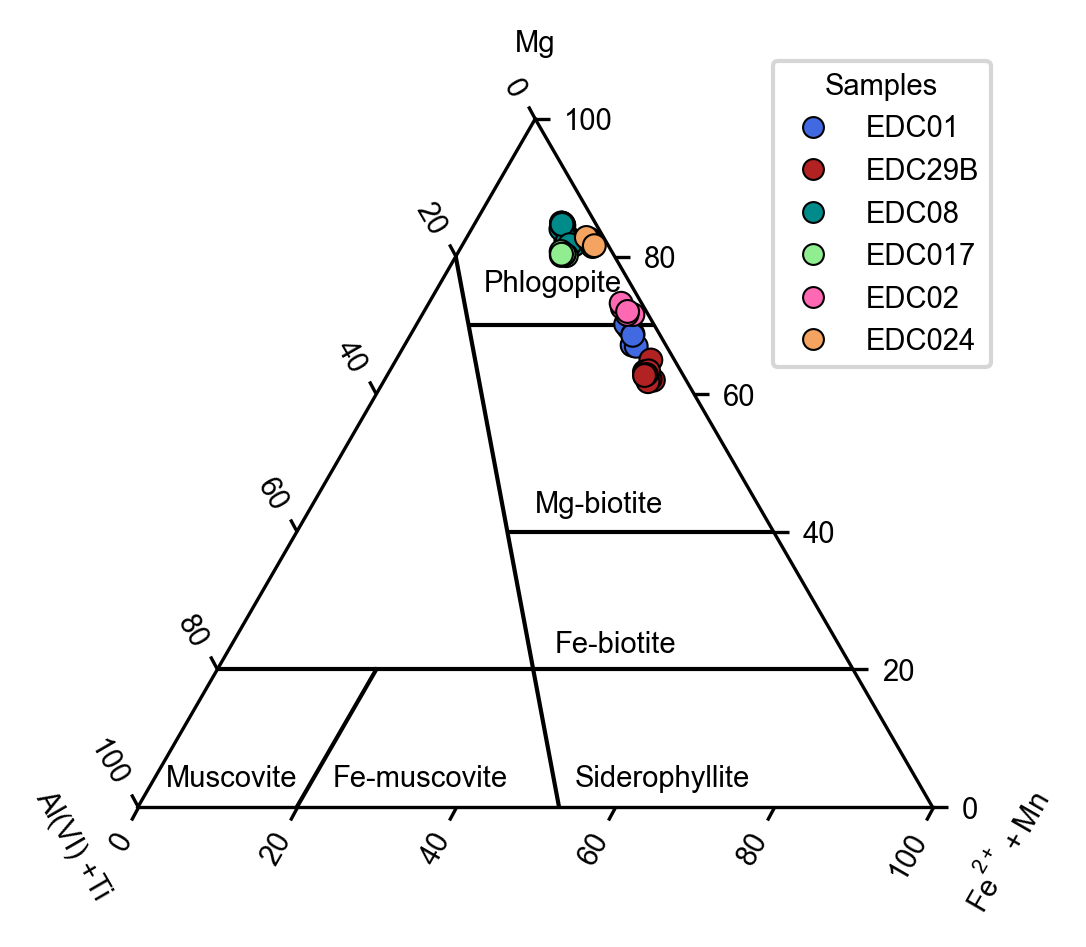

In [7]:
#Values based on paper by Sepidbar et al. (2017) and references therein 
#DOI:10.1016/j.oregeorev.2017.08.029

Draft2 = False

#set figure size
fig = plt.figure(figsize=(89/25.4, 89/25.4), layout='constrained')

#plotting points
ax = fig.add_subplot(projection="ternary", ternary_sum=100)
ax.scatter(top, left, right, s=30, c=colours_assigned, edgecolors='k', linewidth=0.5, zorder=3)

#adding vertices labels 
ax.set_tlabel("Mg", fontsize=7)
ax.set_llabel("Al(VI) +Ti", fontsize=7)
ax.set_rlabel(r"$Fe^{2+} + Mn$", fontsize=7)

#add in compositional boundaries based on Sepidbar et al. (2017)
t1,l1,r1 = [0, 80], [47, 20],[53, 0]
ax.plot(t1, l1, r1, color='k', linewidth=1)

t2,l2,r2 = [20, 20],[0, 80],[80, 0]
ax.plot(t2, l2, r2, color='k', linewidth=1, zorder=2)

t3,l3,r3 = [70, 70],[0, 23],[30, 7]
ax.plot(t3, l3, r3, color='k', linewidth=1, zorder=2)

t4,l4,r4 = [40, 40],[33.3, 0],[26.7, 60]
ax.plot(t4, l4, r4, color='k', linewidth=1, zorder=2)

t5,l5,r5 = [0, 20],[80, 60],[20, 20]
ax.plot(t5, l5, r5, color='k', linewidth=1, zorder=2)

#labelling compositional zones
ax.text(75,19,6,'Phlogopite',fontsize=7)
ax.text(45,30,30,'Mg-biotite',fontsize=7)
ax.text(23,37,42,'Fe-biotite',fontsize=7)
ax.text(3,44,54,'Siderophyllite',fontsize=7)
ax.text(3,74,23,'Fe-muscovite',fontsize=7)
ax.text(3,95,2,'Muscovite',fontsize=7)

#addiing legend
colours2=pd.unique(colours_assigned)
samples=pd.unique(Slide)
legend_elements=[]
for x, y in zip(samples, colours2):
    legend_elements.append(Line2D([0], [0], marker='o', color='w', label=x, markerfacecolor=y, markersize=5, markeredgecolor='k', markeredgewidth=0.5))
plt.legend(handles=legend_elements, loc='upper right', borderaxespad=-2, title="Samples", fontsize=7)

#saving figure
if Draft2 == False:
    plt.savefig("Foster_abstract_ternary.pdf")
    plt.savefig("Foster_abstract_ternary.png")

# Code for magnesium trend with R squared

In [8]:
SiO2 = biotites['   SiO2  ']
MgO = biotites['   MgO   ']

In [9]:
def get_r2(x,y):  
    polyfit = np.polyfit(x,y,1) 
    y_predicted = np.polyval(polyfit,x) 
    residuals = y-y_predicted  
    return 1-np.sum(residuals**2)/np.sum((y-np.mean(y))**2)

#print(get_r2(SiO2,MgO))
fitted_ys=np.polyfit(SiO2,MgO,1)
#print(fitted_ys)

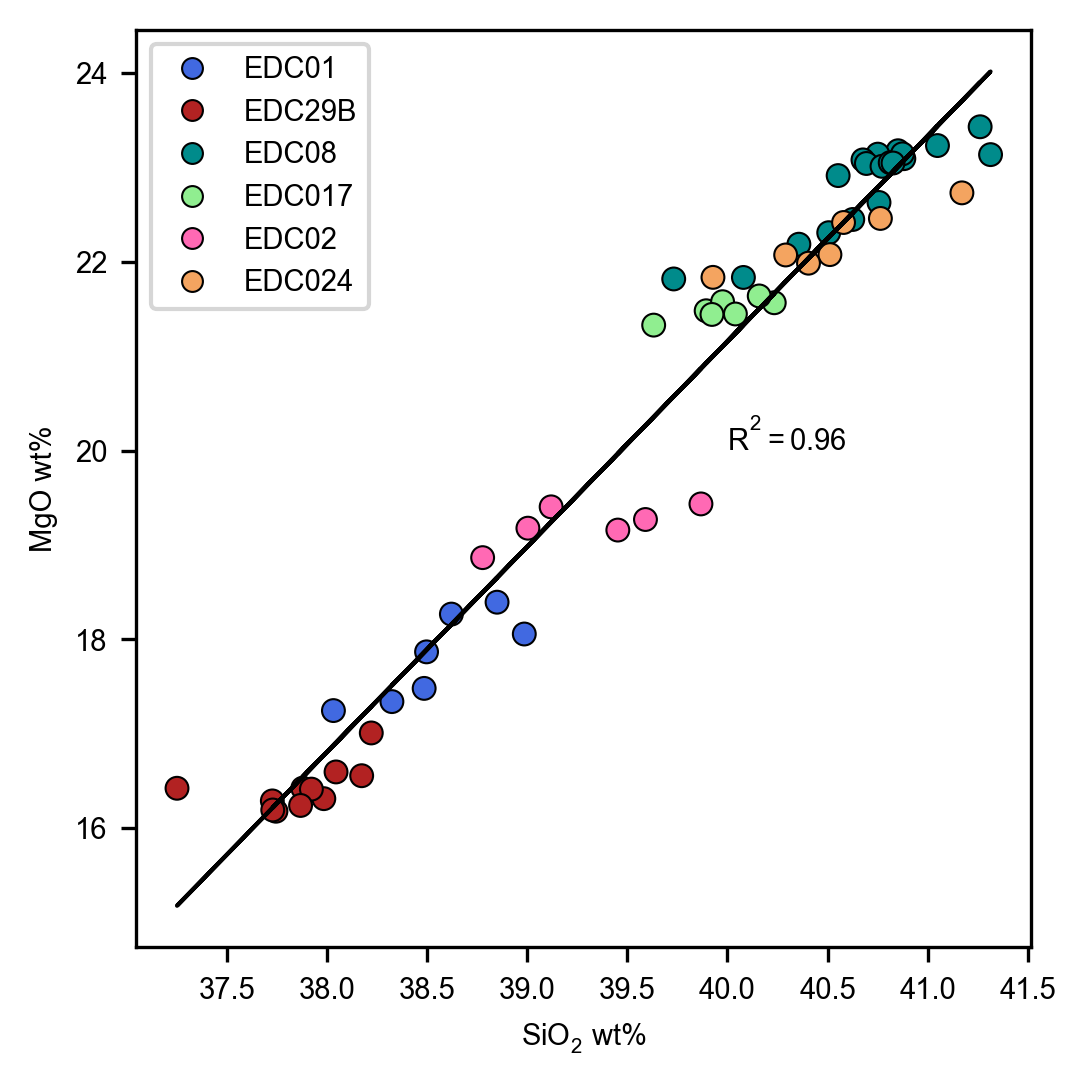

In [16]:
ss=30

Draft4 = False

#set figure size
fig = plt.figure(figsize=(89/25.4, 89/25.4), layout='constrained')

plt.scatter(SiO2,MgO,c=colours_assigned, s=ss, linewidth=0.5, edgecolors='k')
#plt.scatter(Al_2006,X_Fe_2006,c='lightgrey',s=ss, linewidth=0.5, edgecolors='k')

#plt.xlim(1,1.3)
#plt.ylim(0,0.6)

#creating legend
from matplotlib.lines import Line2D

colours2=pd.unique(colours_assigned) #better to use pandas for this as you are parsing the slide numbers which are strings
#print(colours)
samples=pd.unique(Slide)
#print(samples)

legend_elements=[]
for x, y in zip(samples, colours2):
    legend_elements.append(Line2D([0], [0], marker='o', color='w', label=x, markerfacecolor=y, markersize=5, markeredgecolor='k', markeredgewidth=0.5))
#legend_elements.append(Line2D([0], [0], marker='o', color='w', label='Marshal & Oliver 2006', markerfacecolor='lightgrey', markersize=8, markeredgecolor='k', markeredgewidth=0.5))
plt.legend(handles=legend_elements, loc='upper left')

#adding axes labels
plt.xlabel('SiO$_2$ wt%')
plt.ylabel('MgO wt%')

plt.plot(SiO2,np.polyval(fitted_ys,SiO2), color='black', linewidth=1)

r2_text = f'$R^2 = {round(get_r2(SiO2,MgO),2)}$'

plt.text(x=40, y=20, s=r2_text, color='black', fontsize=7, fontweight='bold')

#saving figure
if Draft4 == False:
    plt.savefig("Mg_trend.pdf")
    plt.savefig("Mg_trend.png")

# Code for PCA

## Creating dataframe

In [11]:
#creating pandas data frame for PCA
elements_of_df = ["Slide","   SiO2  ","   MgO   ","   CaO   ","   Al2O3 ","   F     ","   FeO   ","   MnO   ","   TiO2  ","   Cl    ","   Na2O  ","   K2O   "]
biotites_wts = pd. DataFrame(biotites[elements_of_df])
biotites_wts_df=biotites_wts.set_index("Slide")

## Calculations for PCA

In [12]:
#scaling data 
biotites_scaled_data = preprocessing.scale(biotites_wts_df) 

In [13]:
#determining principal components
pca = PCA()
pca_data = pca.fit(biotites_scaled_data) #calculating loading scores and variation 
per_var=np.round(pca.explained_variance_ratio_*100, decimals=1) #percentage of variation for scree plot
pca_data_biotites = pca.transform(biotites_scaled_data) #creating coordinates for PCA graph

In [14]:
#saving PCA coordinates as a data frame for graphing 
labels = ['PC' + str(x) for x in range(1, len(per_var)+1)]
pca_df = pd.DataFrame(pca_data_biotites, index=biotites["Slide"], columns=labels)

## Graph of PC1 and PC2 with inset scree plot

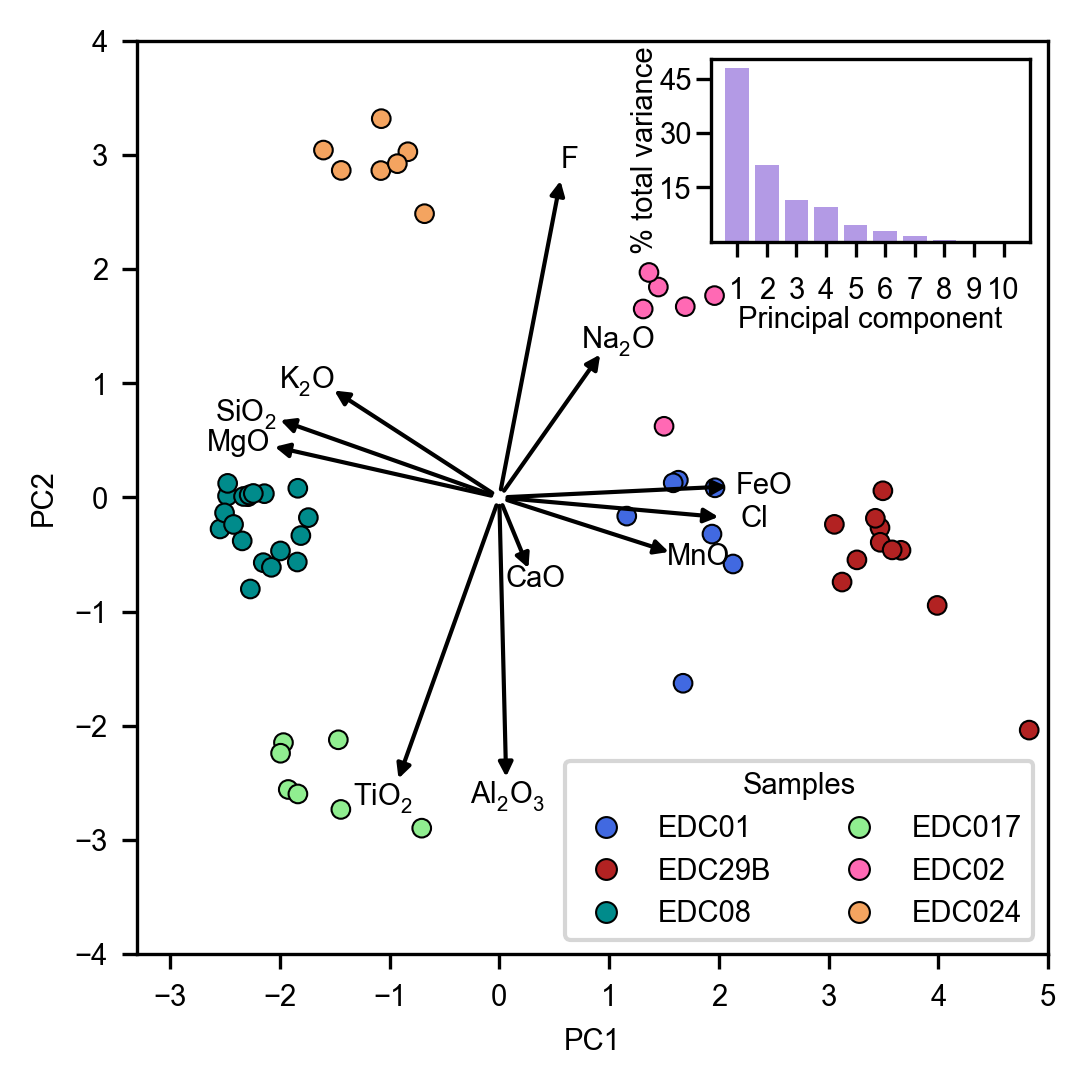

In [15]:
#with vectors

Draft3=False

#setting size
fig, ax = plt.subplots(figsize=(89/25.4, 89/25.4), layout='constrained')

#PCA graph
ax.scatter(pca_df['PC1'],pca_df['PC2'], c=colours_assigned, edgecolor='k', s=20, linewidths=0.5)

#labelling axes
ax.set_xlabel('PC1'.format(per_var[0]), labelpad=4)
ax.set_ylabel('PC2'.format(per_var[1]), labelpad=4)

#setting axes limits
ax.set_xlim(-3.3, 5)
ax.set_ylim(-4, 4)

#adding legend
legend_slides=pd.unique(biotites['Slide'])
legend_colours=pd.unique(colours_assigned)
legend_elements=[]
for x, y in zip(legend_slides, legend_colours):
    legend_elements.append(Line2D([0], [0], marker='o', color='w', label=x, markerfacecolor=y, markersize=5, markeredgecolor='k', markeredgewidth=0.5))
plt.legend(handles=legend_elements, loc='lower right', ncol=2, title="Samples",fontsize=7)

#adding eigen vectors
column_names = (elements_of_df[1:]) #retrieving names of variables
#formatting variable names 
display_names=['SiO$_2$','MgO','CaO','Al$_2$O$_3$','F','FeO','MnO','TiO$_2$','Cl','Na$_2$O','K$_2$O']
#adding vectors as arrows with formatted variable names
loadings = pd.DataFrame(pca_data.components_.T[:, :2], columns=['PC1', 'PC2'], index=column_names)
scale = 5
for i, oxide in enumerate(display_names):
    lx = loadings.iloc[i, 0] * scale
    ly= loadings.iloc[i, 1] * scale
    plt.annotate("",xy=(lx,ly),xytext=(0,0),
                arrowprops = dict(arrowstyle = "-|>", color="k",lw=1))
    plt.text(lx*1.12, ly*1.04, oxide, color="k", fontsize=7, ha="center", va="center")

#adding an inset scree plot

#axes proportions
axin2 = ax.inset_axes([0.63, 0.78, 0.35, 0.20])

#data to be graphed 
## PCA11 is removed for graphical simplicity as it does not show a significant percentage
axin2.bar(x=range(1,len(per_var)), height=per_var[:10], tick_label=labels[:10], color='mediumpurple', alpha=0.7)

#adding axis labels 
axin2.set_ylabel('% total variance', fontsize=7,labelpad=0.1)
axin2.set_xlabel('Principal component',fontsize=7,labelpad=0.1)

#adding labelled tick marks
yticks=[15,30,45]
index_num=np.arange(1, len(per_var))
axin2.set_xticklabels(index_num)
axin2.set_yticks(yticks)
axin2.tick_params(axis='both', which='major', labelsize=7,pad=5)
plt.setp(axin2.get_xticklabels(), rotation=0, ha="center",fontsize=7)
plt.setp(axin2.get_yticklabels(), rotation=0, ha="center",fontsize=7)


#saving figure
if Draft3 == False:
    plt.savefig("PCA_abstract_w_inset.pdf" )
    plt.savefig("PCA_abstract_w_inset.png")